In [1]:
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/evaluation/Chatbot Performance Q&A.csv')

In [3]:
df.columns

Index(['Timestamp', 'Username',
       'O chatbot foi fácil de aceder e começar a utilizar.',
       'Interagir com o chatbot foi intuitivo e exigiu pouco esforço.',
       'Consegui encontrar a informação de que precisava sem dificuldade.',
       'As respostas do chatbot foram precisas e factualmente corretas.',
       'A informação fornecida foi relevante para as minhas questões sobre os procedimentos do PT2030 e do IAPMEI.',
       'O nível de detalhe das respostas foi adequado.',
       'Confio na informação dada pelo chatbot.',
       'No geral, estou satisfeito(a) com o chatbot como ferramenta de apoio à informação.',
       'Consideraria utilizar este chatbot nas minhas atividades profissionais regulares.',
       'Consideraria utilizar este chatbot para rapidamente clarificar questões acerca dos incentivos PT2030',
       'O chatbot acrescenta valor em comparação com os métodos tradicionais de acesso à informação (por exemplo, websites ou documentos).',
       'Que limitações 

In [4]:
df.columns = [
    "timestamp", "username",
    "Q1", "Q2", "Q3",
    "Q4", "Q5", "Q6",
    "Q7", "Q8", "Q9",
    "Q10", "Q11",
    "Q12", "Q13"
]


In [5]:
df.describe()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11
count,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000
mean,4.352941,4.352941,3.823529,3.647059,3.882353,3.705882,3.529412,3.705882,3.882353,3.705882,3.823529
std,0.701888,0.606339,0.951006,1.057188,0.927520,0.985184,1.007326,0.848875,0.927520,0.919559,1.014599
min,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


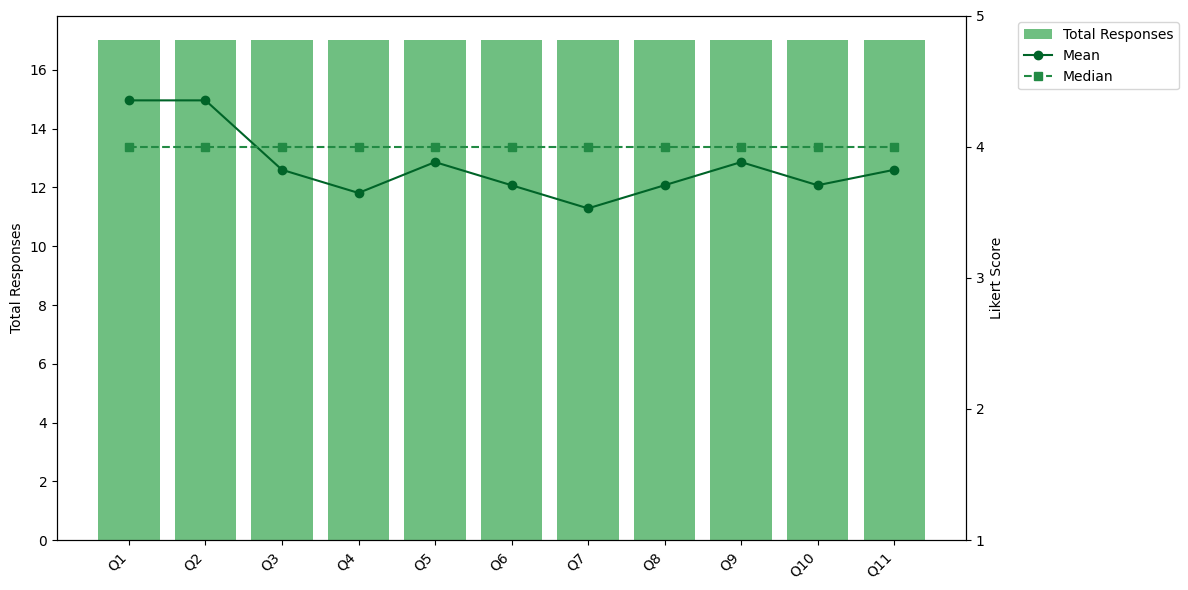

In [9]:
# Select Likert columns
data = df.iloc[:, 2:13]

# Compute stats
counts = data.count()
means = data.mean()
medians = data.median()

x = np.arange(len(counts))

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- BAR: counts (primary axis) ---
bar_color = plt.cm.Greens(0.6)
ax1.bar(x, counts, color=bar_color, alpha=0.8, label="Total Responses")
ax1.set_ylabel("Total Responses")
ax1.set_xticks(x)
ax1.set_xticklabels(counts.index, rotation=45, ha='right')

# --- LINE: mean & median (secondary axis) ---
ax2 = ax1.twinx()

ax2.plot(x, means, marker='o', color=plt.cm.Greens(0.9), label='Mean')
ax2.plot(x, medians, marker='s', linestyle='--', color=plt.cm.Greens(0.75), label='Median')

# IMPORTANT: Likert scale (adjust if needed)
ax2.set_ylim(1, 5)
ax2.set_yticks([1, 2, 3, 4, 5])
ax2.set_ylabel("Likert Score")

# --- Legend (combine both axes) ---
lines, labels = ax2.get_legend_handles_labels()
bars, bar_labels = ax1.get_legend_handles_labels()
ax2.legend(bars + lines, bar_labels + labels, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [6]:
likert = df.iloc[:, 2:13]
likert_percent = {}

for col in likert.columns:
    counts = likert[col].value_counts(normalize=True).sort_index() * 100
    likert_percent[col] = counts

likert_df = pd.DataFrame(likert_percent).T.fillna(0)

In [7]:
likert_df

,2,3,4,5
Q1,0.000000,11.764706,41.176471,47.058824
Q2,0.000000,5.882353,52.941176,41.176471
Q3,11.764706,17.647059,47.058824,23.529412
Q4,17.647059,23.529412,35.294118,23.529412
Q5,11.764706,11.764706,52.941176,23.529412
Q6,11.764706,29.411765,35.294118,23.529412
Q7,17.647059,29.411765,35.294118,17.647059
Q8,5.882353,35.294118,41.176471,17.647059
Q9,5.882353,29.411765,35.294118,29.411765
Q10,5.882353,41.176471,29.411765,23.529412


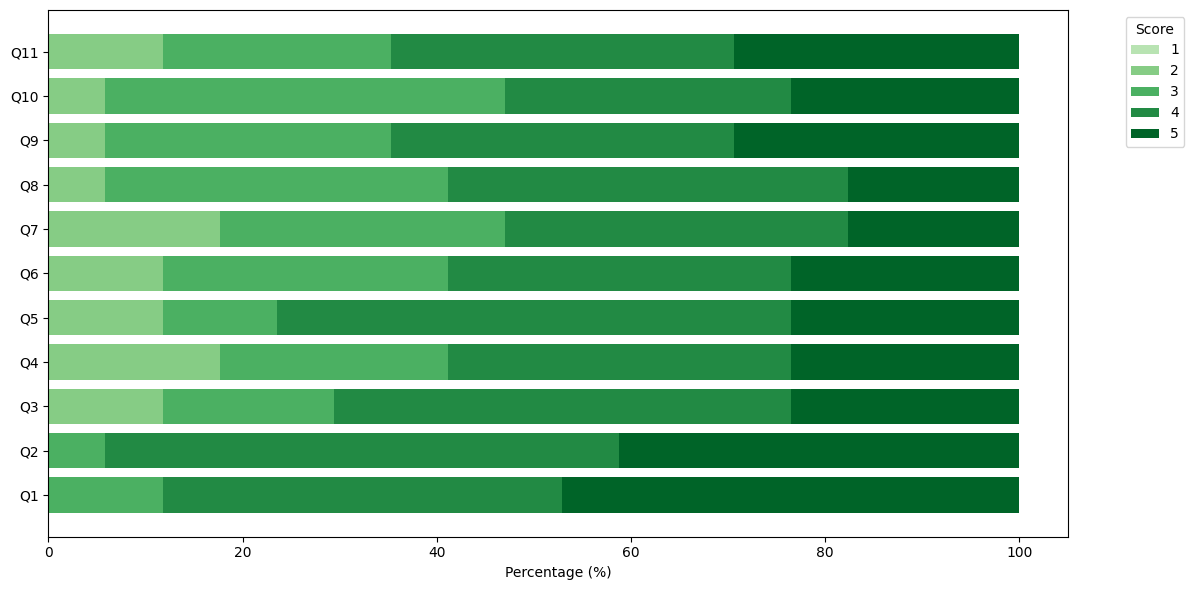

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Define order of responses
categories = [1, 2, 3, 4, 5]

# Create green color gradient
cmap = plt.cm.Greens
colors = cmap(np.linspace(0.3, 0.9, len(categories)))  

fig, ax = plt.subplots(figsize=(12, 6))

left = [0] * len(likert_df)

for i, cat in enumerate(categories):
    values = likert_df[cat] if cat in likert_df.columns else [0]*len(likert_df)
    #print(values)
    ax.barh(
        likert_df.index,
        values,
        left=left,
        label=f"{cat}",
        color=colors[i]
    )
    left = [l + v for l, v in zip(left, values)]

ax.set_xlabel("Percentage (%)")
ax.legend(title="Score", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [47]:
pd.set_option('display.max_colwidth', None)

df['Q13']

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              NaN
1                                    